## What if togliessimo le variabili che fanno rumore?

Come primo passo, carico le librerie e il dataset, elimino le variabili id_participant e quelle degli studenti

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression

# Librerie per Random Forest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import LeaveOneOut
from sklearn.utils import class_weight
from statsmodels.gam.gam_cross_validation.cross_validators import KFold

In [40]:
df = pd.read_csv('../df_encoded.csv')
# Identifico le colonne numeriche da lasciare, eliminando l'occupation type e l'identity
df = df.drop(['occupation_Student', 'occupation_Working Professional', 'occupation_Freelancer', "participant_id"], axis=1)

print(df.shape)
X = df.drop("side_effects", axis=1)
y = df['side_effects']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,           # 20% per il test
    random_state=42,         # Per reproducibilità
    stratify=y               # Mantiene le proporzioni delle classi
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)




(500, 8)


In [41]:
from sklearn.metrics import f1_score, make_scorer
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Inizializzazione e addestramento del modello
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42, max_iter=2000))
])

param_grid = [
    # Ridge (L2)
    {
        'model__C': np.logspace(-3, 2, 6),
        'model__class_weight': [None, 'balanced'],
        'model__solver': ['lbfgs']
    },

    # Lasso (L1)
    {
        'model__C': np.logspace(-3, 2, 6),
        'model__class_weight': [None, 'balanced'],
        'model__solver': ['saga']
    },

    # ElasticNet
    {
        'model__C': np.logspace(-3, 2, 6),
        'model__l1_ratio': [0.2, 0.5, 0.8],
        'model__class_weight': ['balanced'],
        'model__solver': ['saga']
    }
]

logistic_regressor = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

# Addestramento
print("\n--- Addestramento del modello ---")
logistic_regressor.fit(X_train, y_train)
print("Modello addestrato!")

y_pred = logistic_regressor.predict(X_test)
print(classification_report(y_test, y_pred))

# Accuratezza su train e test set
train_accuracy = logistic_regressor.score(X_train, y_train)
test_accuracy = logistic_regressor.score(X_test, y_test)

print(f"\nAccuratezza sul Train Set: {train_accuracy:.4f}")
print(f"Accuratezza sul Test Set: {test_accuracy:.4f}")
print(logistic_regressor.best_estimator_) #per vedere gli iperparametri scelti


--- Addestramento del modello ---
Fitting 5 folds for each of 42 candidates, totalling 210 fits
Modello addestrato!
              precision    recall  f1-score   support

           0       0.32      0.40      0.35        15
           1       0.28      0.25      0.26        20
           2       0.50      0.33      0.40        24
           3       0.47      0.54      0.50        41

    accuracy                           0.41       100
   macro avg       0.39      0.38      0.38       100
weighted avg       0.41      0.41      0.41       100


Accuratezza sul Train Set: 0.4751
Accuratezza sul Test Set: 0.3790
Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(C=np.float64(10.0), max_iter=2000,
                                    random_state=42))])


Bhe, almeno ci ho provato

Il modello fa schifo perché, indovina indovinello, i dati fanno schifo! Garbage in garbage out babyyyyy

Questo ci dice che:

Classe 1 (Crash): recall 0.75 → il modello la sovrastima (la predice troppo spesso)
Classe 3 (None): recall 0.34 → il modello ha le maggiori difficoltà con questa classe (la riconosce poco e male)


=== CONFUSION MATRIX ===
[[ 6  7  0  2]
 [ 8  5  0  7]
 [ 0  0  8 16]
 [ 5  6  8 22]]


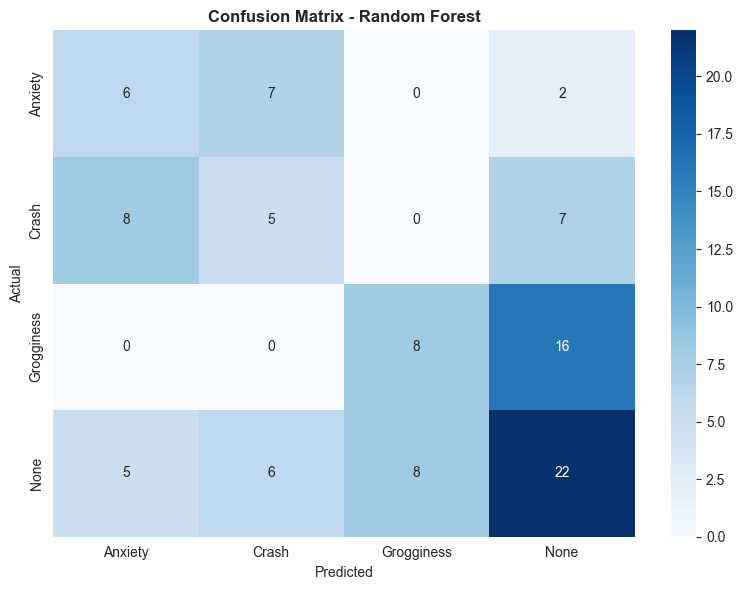

In [42]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print("\n=== CONFUSION MATRIX ===")
print(cm)

# Heatmap della confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Anxiety', 'Crash', 'Grogginess', 'None'],
            yticklabels=['Anxiety', 'Crash', 'Grogginess', 'None'])
ax.set_title('Confusion Matrix - Random Forest', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

Questo dataset mi ricorda la mia relazione con il mio ex: le red flag c'erano fin dall'inizio, sono io che ho deciso di ignorarle. Si può vedere che il modello usa la classe dominante come default, e dato che abbiamo visto che nella PCA la classe None è difficilmente clusterizzabile, la elimino <3

(293, 8)

--- Addestramento del modello ---
Fitting 5 folds for each of 42 candidates, totalling 210 fits
Modello addestrato!
              precision    recall  f1-score   support

           0       0.50      0.73      0.59        15
           1       0.69      0.45      0.55        20
           2       1.00      1.00      1.00        24

    accuracy                           0.75        59
   macro avg       0.73      0.73      0.71        59
weighted avg       0.77      0.75      0.74        59


Accuratezza sul Train Set: 0.7258
Accuratezza sul Test Set: 0.7133
Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(C=np.float64(0.1), class_weight='balanced',
                                    l1_ratio=0.8, max_iter=2000,
                                    random_state=42, solver='saga'))])

=== CONFUSION MATRIX ===
[[11  4  0]
 [11  9  0]
 [ 0  0 24]]


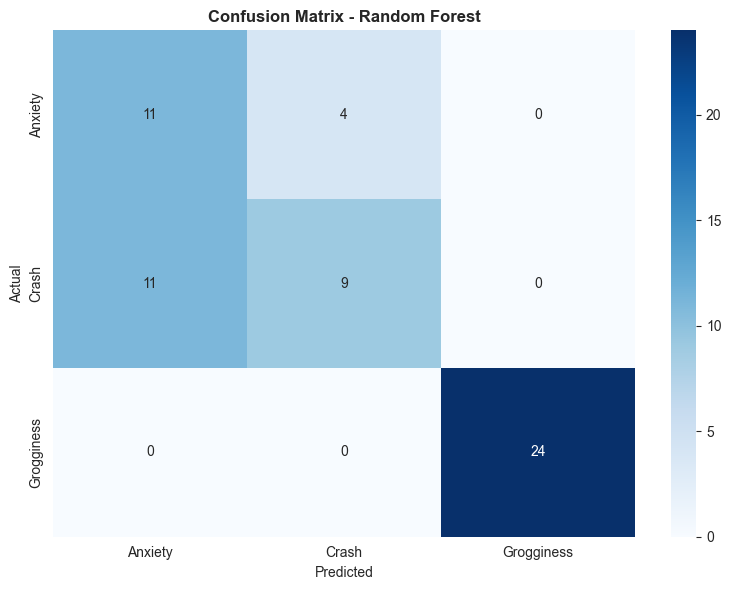

In [43]:
df = pd.read_csv('../df_encoded.csv')
# Identifico le colonne numeriche da lasciare, eliminando l'occupation type e l'identity
df = df.drop(['occupation_Student', 'occupation_Working Professional', 'occupation_Freelancer', "participant_id"], axis=1)
df = df[df["side_effects"] != 3]
print(df.shape)
X = df.drop("side_effects", axis=1)
y = df['side_effects']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,           # 20% per il test
    random_state=42,         # Per reproducibilità
    stratify=y               # Mantiene le proporzioni delle classi
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)


pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42, max_iter=2000))
])

param_grid = [
    # Ridge (L2)
    {
        'model__C': np.logspace(-3, 2, 6),
        'model__class_weight': [None, 'balanced'],
        'model__solver': ['lbfgs']
    },

    # Lasso (L1)
    {
        'model__C': np.logspace(-3, 2, 6),
        'model__class_weight': [None, 'balanced'],
        'model__solver': ['saga']
    },

    # ElasticNet
    {
        'model__C': np.logspace(-3, 2, 6),
        'model__l1_ratio': [0.2, 0.5, 0.8],
        'model__class_weight': ['balanced'],
        'model__solver': ['saga']
    }
]

logistic_regressor = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

# Addestramento
print("\n--- Addestramento del modello ---")
logistic_regressor.fit(X_train, y_train)
print("Modello addestrato!")

y_pred = logistic_regressor.predict(X_test)
print(classification_report(y_test, y_pred))

# Accuratezza su train e test set
train_accuracy = logistic_regressor.score(X_train, y_train)
test_accuracy = logistic_regressor.score(X_test, y_test)

print(f"\nAccuratezza sul Train Set: {train_accuracy:.4f}")
print(f"Accuratezza sul Test Set: {test_accuracy:.4f}")
print(logistic_regressor.best_estimator_) #per vedere gli iperparametri scelti

cm = confusion_matrix(y_test, y_pred)
print("\n=== CONFUSION MATRIX ===")
print(cm)

# Heatmap della confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Anxiety', 'Crash', 'Grogginess'],
            yticklabels=['Anxiety', 'Crash', 'Grogginess'])
ax.set_title('Confusion Matrix - Random Forest', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()


Le classi Ansia e Crash sono collassate, coerentemente con il random forest (il che ci sta). Still garbage in garbage out

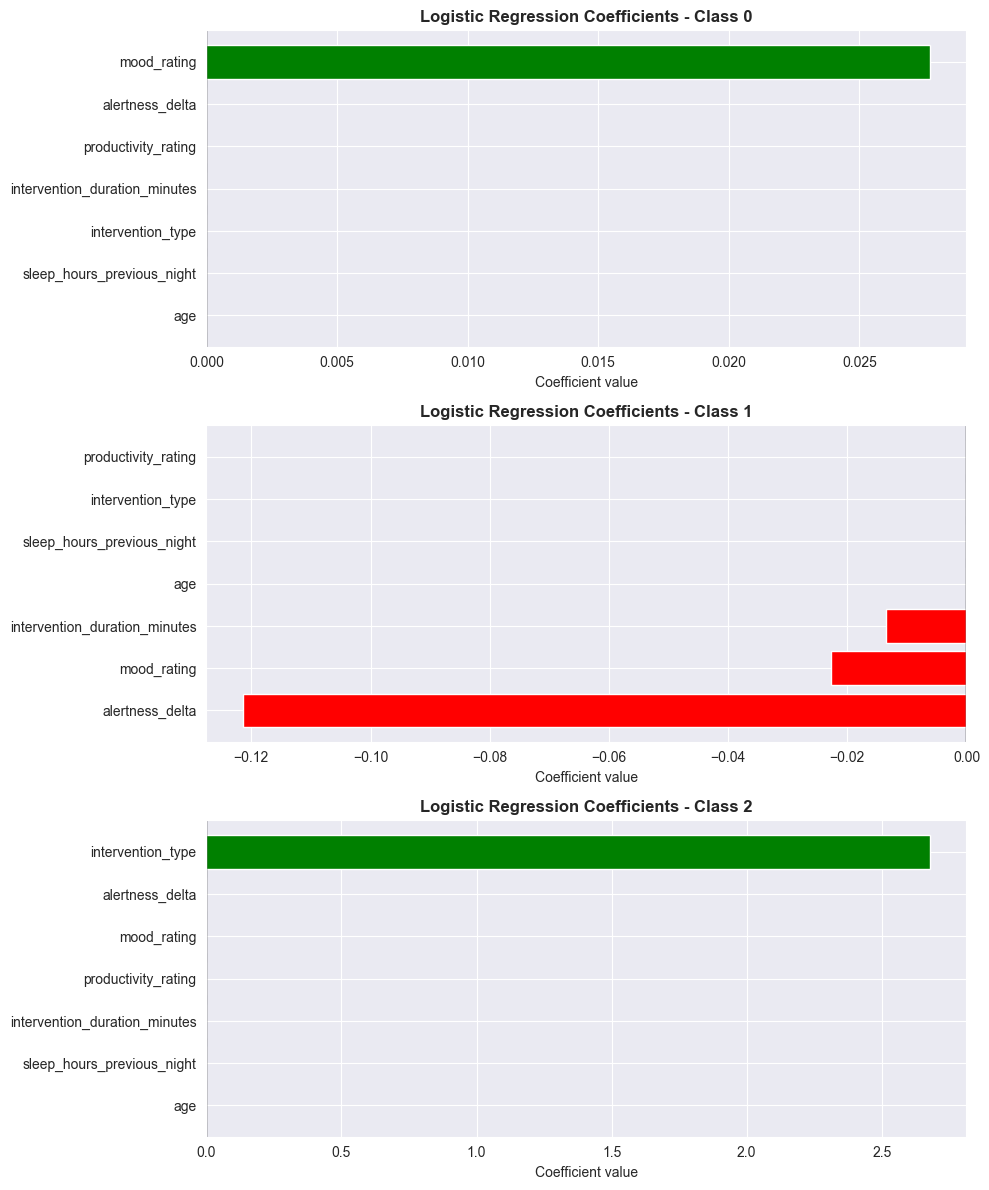

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# prendo il modello migliore dal GridSearch
best_model = logistic_regressor.best_estimator_.named_steps['model']

# feature names (IMPORTANT: usa X_train_raw, non scaled)
feature_names = X_train_raw.columns

# coefficienti del modello (multiclasse: shape = n_classes x n_features)
coefs = best_model.coef_

# class labels
classes = best_model.classes_

# =========================
# PLOT POS/NEG PER CLASSE
# =========================

fig, axes = plt.subplots(len(classes), 1, figsize=(10, 4 * len(classes)))

if len(classes) == 1:
    axes = [axes]

for i, cls in enumerate(classes):
    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coef": coefs[i]
    }).sort_values("coef")

    colors = coef_df["coef"].apply(lambda x: "green" if x > 0 else "red")

    axes[i].barh(coef_df["feature"], coef_df["coef"], color=colors)
    axes[i].axvline(0, color="black", linewidth=1)
    axes[i].set_title(f"Logistic Regression Coefficients - Class {cls}", fontweight="bold")
    axes[i].set_xlabel("Coefficient value")

plt.tight_layout()
plt.show()

## La side quest di Alice verso un modello sensato

Cambiamo per un attimo il task... facciamo finta che voglio predire il tipo di intervento, dato che secondo me è un dataset sintetico che ti fa fare un solo task, cioè questo. Dato che so stronza rifaccio tutto daccapo

In [59]:
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('../power_nap_vs_coffee_effectiveness_dataset.csv')
df = df.drop("participant_id",axis=1)
df = df.dropna()

#alertness_delta
df["alertness_delta"] = df["alertness_score_after"] - df["alertness_score_before"]
df = df.drop(["alertness_score_after", "alertness_score_before"],axis=1)

#encoding: dummies per le categorie non target, 0 e 1 per i tipi di intervento
df=pd.get_dummies(df, columns=["occupation", "side_effects"])
le = LabelEncoder()
df["intervention_type"] = le.fit_transform(df["intervention_type"])

#Controllo se l'intervento ha funzionato
df.head()


,age,sleep_hours_previous_night,intervention_type,intervention_duration_minutes,productivity_rating,mood_rating,alertness_delta,occupation_Freelancer,occupation_Student,occupation_Working Professional,side_effects_Anxiety,side_effects_Crash,side_effects_Grogginess
0,24,5.4,1,15,5,10,15,False,False,True,False,False,True
2,32,4.4,0,30,2,5,8,False,False,True,True,False,False
3,28,6.9,0,30,4,6,11,False,True,False,False,True,False
4,25,4.7,1,30,3,6,18,False,False,True,False,False,True
7,43,4.4,1,25,5,10,20,False,True,False,False,False,True


In [60]:
X = df.drop("intervention_type", axis=1)
y = df['intervention_type']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,           # 20% per il test
    random_state=42,         # Per reproducibilità
    stratify=y               # Mantiene le proporzioni delle classi
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

[1 0]



--- Addestramento del modello ---
Fitting 5 folds for each of 42 candidates, totalling 210 fits
Modello addestrato!
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       1.00      1.00      1.00        24

    accuracy                           1.00        59
   macro avg       1.00      1.00      1.00        59
weighted avg       1.00      1.00      1.00        59


Accuratezza sul Train Set: 1.0000
Accuratezza sul Test Set: 1.0000
Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(C=np.float64(0.001),
                                    class_weight='balanced', max_iter=2000,
                                    random_state=42))])

=== CONFUSION MATRIX ===
[[35  0]
 [ 0 24]]


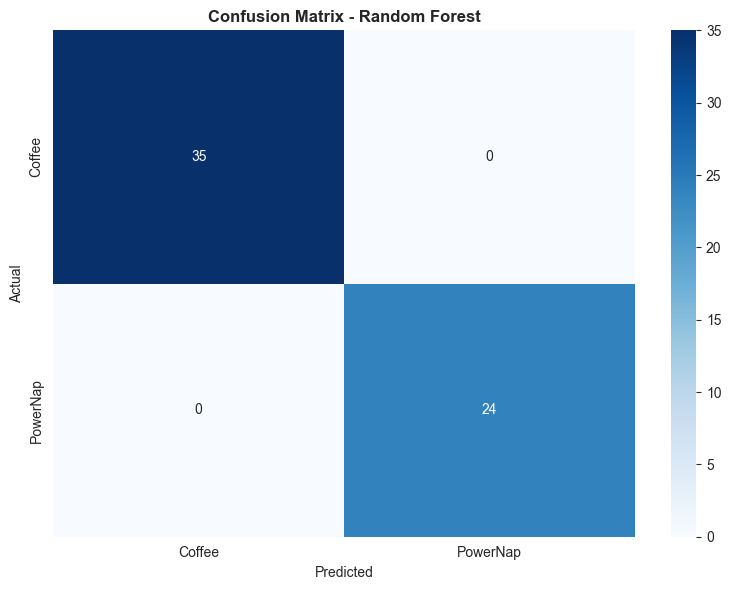

In [62]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42, max_iter=2000))
])

param_grid = [
    # Ridge (L2)
    {
        'model__C': np.logspace(-3, 2, 6),
        'model__class_weight': [None, 'balanced'],
        'model__solver': ['lbfgs']
    },

    # Lasso (L1)
    {
        'model__C': np.logspace(-3, 2, 6),
        'model__class_weight': [None, 'balanced'],
        'model__solver': ['saga']
    },

    # ElasticNet
    {
        'model__C': np.logspace(-3, 2, 6),
        'model__l1_ratio': [0.2, 0.5, 0.8],
        'model__class_weight': ['balanced'],
        'model__solver': ['saga']
    }
]

logistic_regressor = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

# Addestramento
print("\n--- Addestramento del modello ---")
logistic_regressor.fit(X_train, y_train)
print("Modello addestrato!")

y_pred = logistic_regressor.predict(X_test)
print(classification_report(y_test, y_pred))

# Accuratezza su train e test set
train_accuracy = logistic_regressor.score(X_train, y_train)
test_accuracy = logistic_regressor.score(X_test, y_test)

print(f"\nAccuratezza sul Train Set: {train_accuracy:.4f}")
print(f"Accuratezza sul Test Set: {test_accuracy:.4f}")
print(logistic_regressor.best_estimator_)  #per vedere gli iperparametri scelti

cm = confusion_matrix(y_test, y_pred)
print("\n=== CONFUSION MATRIX ===")
print(cm)

# Heatmap della confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Coffee', 'PowerNap'],
            yticklabels=['Coffee', 'PowerNap'])
ax.set_title('Confusion Matrix - Random Forest', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()


ma che strano, mo va tutto benissimo porco dio. Facciamo anche il random forest perchè odio la mia vita e odio passare la pasqua in modo normale

In [64]:
# Inizializzazione e addestramento del modello
# Il numero di alberi e la profondità sono stati suggeriti da Claude sulla base del nostro database
f1 = make_scorer(f1_score, average='weighted') #metto come errore la macro f1, dato che è meglio per i dati sbilanciati, come i nostri
rf_model = GridSearchCV(
            estimator=RandomForestClassifier(random_state = 42),
            param_grid={"n_estimators": [50, 100, 150, 200],
                        "max_depth": [3, 5, 7, 10],  # più basso!,
                        "min_samples_split": [10],
                        "min_samples_leaf": [5, 10, 20],
                        "class_weight": [None, 'balanced', 'balanced_subsample']},
            cv=StratifiedKFold(n_splits=5),
            scoring=f1, #uso come scoring l'f1
            n_jobs=-1
        )

# Addestramento
print("\n--- Addestramento del modello ---")
rf_model.fit(X_train, y_train)
print("Modello addestrato!")

# Accuratezza su train e test set
train_accuracy = rf_model.score(X_train, y_train)
test_accuracy = rf_model.score(X_test, y_test)

print(f"\nAccuratezza sul Train Set: {train_accuracy:.4f}")
print(f"Accuratezza sul Test Set: {test_accuracy:.4f}")
print(rf_model.best_estimator_)


--- Addestramento del modello ---
Modello addestrato!

Accuratezza sul Train Set: 1.0000
Accuratezza sul Test Set: 1.0000
RandomForestClassifier(max_depth=3, min_samples_leaf=5, min_samples_split=10,
                       n_estimators=50, random_state=42)


Feature Importance:
                            Feature  Importance
11          side_effects_Grogginess    0.421639
10               side_effects_Crash    0.221307
5                   alertness_delta    0.187484
9              side_effects_Anxiety    0.131249
1        sleep_hours_previous_night    0.011024
4                       mood_rating    0.007724
0                               age    0.006028
7                occupation_Student    0.004655
3               productivity_rating    0.004515
2     intervention_duration_minutes    0.003174
8   occupation_Working Professional    0.000920
6             occupation_Freelancer    0.000282


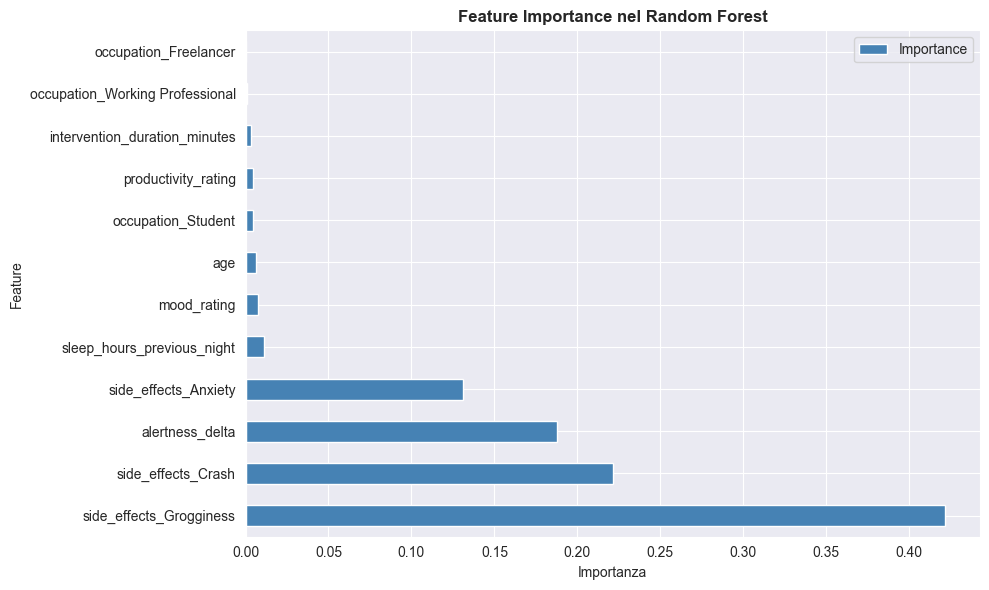

In [65]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.best_estimator_.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance:")
print(feature_importance)

# Grafico
fig, ax = plt.subplots(figsize=(10, 6))
feature_importance.plot(x='Feature', y='Importance', kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance nel Random Forest', fontsize=12, fontweight='bold')
ax.set_xlabel('Importanza')
plt.tight_layout()
plt.show()

bhe amici, questo dataset era palesemente sintetico per far avere questo risultato qua... comunque what if the perfectly accurate ml model were the friends we made along the way?